# Analisis Data Penjualan

## Rumusan Masalah
1. Bagaimana **tren penjualan dan profit** berubah dari waktu ke waktu (bulanan & tahunan)?
2. **Channel penjualan** mana yang memberikan kontribusi terbesar terhadap total penjualan dan profitabilitas?
3. **Region** mana yang memiliki performa penjualan tertinggi?
4. **Kategori dan sub-kategori produk** apa yang paling diminati dan menguntungkan?
5. Bagaimana **profit margin** bervariasi di antara kategori produk dan channel penjualan?
6. Apakah terdapat **transaksi dengan profit negatif (kerugian)**? Seberapa signifikan?
7. Bagaimana performa penjualan berdasarkan **negara dan kota**?
8. Bagaimana **pola penjualan berdasarkan hari** dalam seminggu?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

In [2]:
RAW_COLUMN_MAP = {
    "Order Date": "order_date",
    "Year": "year",
    "Order Qty": "order_qty",
    "Cost of Sales": "cost_of_sales",
    "Sales": "sales",
    "Profit": "profit",
    "Channel": "channel",
    "Product Name": "product_name",
    "Manufacturer": "manufacturer",
    "Brand Name": "brand_name",
    "Product Sub Category": "product_sub_category",
    "Product Category": "product_category",
    "Region": "region",
    "City": "city",
    "Country": "country",
}

SEARCH_ROOTS = [Path.cwd(), Path.cwd().parent]
DATA_CANDIDATES = [
    "SalesData.xlsx",
    "salesdata.xlsx",
    "data/SalesData.xlsx",
    "data/salesdata.xlsx",
]

def find_file(candidates=DATA_CANDIDATES):
    for root in SEARCH_ROOTS:
        for candidate in candidates:
            path = (root / candidate).resolve()
            if path.exists():
                return path
    return None

def load_sales_data(path=None):
    data_path = Path(path) if path is not None else find_file()
    if data_path is None:
        raise FileNotFoundError("SalesData.xlsx tidak ditemukan di workspace.")
    return pd.read_excel(data_path)

def clean_sales_data(df):
    cleaned = df.copy()
    cleaned.columns = [column.strip() for column in cleaned.columns]
    cleaned = cleaned.rename(columns=RAW_COLUMN_MAP)

    if "order_date" not in cleaned.columns:
        raise KeyError("Kolom 'Order Date' tidak ditemukan pada data.")

    cleaned["order_date"] = pd.to_datetime(cleaned["order_date"], errors="coerce")
    cleaned = cleaned.dropna(subset=["order_date"]).copy()

    for column in ["order_qty", "cost_of_sales", "sales", "profit"]:
        if column in cleaned.columns:
            cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce").fillna(0)

    for column in [
        "channel",
        "product_name",
        "manufacturer",
        "brand_name",
        "product_sub_category",
        "product_category",
        "region",
        "city",
        "country",
    ]:
        if column in cleaned.columns:
            cleaned[column] = cleaned[column].astype(str).str.strip()

    cleaned["year"] = cleaned["order_date"].dt.year.astype("int64")
    cleaned["month"] = cleaned["order_date"].dt.month.astype("int64")
    cleaned["month_name"] = cleaned["order_date"].dt.strftime("%b")
    cleaned["order_month"] = cleaned["order_date"].dt.to_period("M").dt.to_timestamp()
    cleaned["order_day_name"] = cleaned["order_date"].dt.day_name()

    cleaned["profit_margin"] = np.where(
        cleaned["sales"] != 0,
        cleaned["profit"] / cleaned["sales"],
        0,
    )

    cleaned = cleaned.sort_values("order_date").reset_index(drop=True)
    return cleaned

def quality_report(df):
    report = {
        "rows": int(df.shape[0]),
        "columns": int(df.shape[1]),
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }

    if "order_date" in df.columns and "year" in df.columns:
        report["date_range"] = (df["order_date"].min(), df["order_date"].max())
        report["year_mismatches"] = int((df["order_date"].dt.year != df["year"]).sum())
    return report

def metric_summary(df):
    return {
        "total_sales": float(df["sales"].sum()),
        "total_profit": float(df["profit"].sum()),
        "total_orders": float(df.shape[0]),
        "total_quantity": float(df["order_qty"].sum()),
        "avg_profit_margin": float(df["profit_margin"].mean()),
    }

def top_n_by_metric(df, group_column, metric="sales", n=10):
    summary = (
        df.groupby(group_column, as_index=False)
        .agg({metric: "sum", "profit": "sum", "order_qty": "sum"})
        .sort_values(metric, ascending=False)
        .head(n)
    )
    return summary

def monthly_summary(df):
    summary = (
        df.groupby("order_month", as_index=False)
        .agg(
            sales=("sales", "sum"),
            profit=("profit", "sum"),
            order_qty=("order_qty", "sum"),
        )
        .sort_values("order_month")
    )
    return summary

## Data Wrangling
### Gathering Data

In [3]:
raw_df = load_sales_data()
print(f'Shape: {raw_df.shape}')
raw_df.head()

Shape: (15000, 15)


,Order Date,Year,Order Qty,Cost of Sales,Sales,Profit,Channel,Product Name,Manufacturer,Brand Name,Product Sub Category,Product Category,Region,City,Country
0,2019-05-16,2019,9,958.552406,2714.7200,1756.167594,Store,Contoso SLR Camera M143 Grey,"Contoso, Ltd",Contoso,Digital SLR Cameras,Cameras and camcorders,Europe,Moscow,Russia
1,2018-04-22,2018,4,18.624692,50.1414,31.516708,Store,Contoso 512MB MP3 Player E51 Blue,"Contoso, Ltd",Contoso,MP4&MP3,Audio,Europe,Moscow,Russia
2,2018-03-10,2018,9,205.101455,1395.1128,1190.011345,Store,Contoso DVD 9-Inch Player Portable M300 Silver,"Contoso, Ltd",Contoso,Movie DVD,"Music, Movies and Audio Books",Europe,Moscow,Russia
3,2020-04-12,2020,18,6.619718,462.4200,455.800282,Store,NT Bluetooth Stereo Headphones E52 Pink,Northwind Traders,Northwind Traders,Bluetooth Headphones,Audio,North America,Bellevue,United States
4,2019-03-17,2019,9,4.807085,2614.4000,2609.592915,Online,Contoso SLR Camera M143 Grey,"Contoso, Ltd",Contoso,Digital SLR Cameras,Cameras and camcorders,Asia,Beijing,China


### Assessing Data

In [4]:
print('=== Info ===')
raw_df.info()
print('\n=== Describe ===')
raw_df.describe()

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order Date            15000 non-null  datetime64[ns]
 1   Year                  15000 non-null  int64         
 2   Order Qty             15000 non-null  int64         
 3   Cost of Sales         15000 non-null  float64       
 4   Sales                 15000 non-null  float64       
 5   Profit                15000 non-null  float64       
 6   Channel               15000 non-null  object        
 7   Product Name          15000 non-null  object        
 8   Manufacturer          15000 non-null  object        
 9   Brand Name            15000 non-null  object        
 10  Product Sub Category  15000 non-null  object        
 11  Product Category      15000 non-null  object        
 12  Region                15000 non-null  object        
 13  Cit

,Order Date,Year,Order Qty,Cost of Sales,Sales,Profit
count,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,2019-06-01 02:00:23.040000,2018.913667,16.741733,1320.158980,3692.783986,2372.625006
min,2018-02-02 00:00:00,2018.000000,4.000000,0.000797,4.750000,-51633.408168
25%,2018-08-26 00:00:00,2018.000000,9.000000,63.786125,645.000000,218.431321
50%,2019-04-19 00:00:00,2019.000000,10.000000,313.199817,2301.175750,1269.087695
75%,2020-02-18 00:00:00,2020.000000,13.000000,1275.884277,4767.720000,3222.444388
max,2021-02-01 00:00:00,2021.000000,1560.000000,80260.636168,78312.000000,67439.594523
std,NaN,0.859998,43.490032,3082.896420,4917.886955,4326.165116


### Cleaning Data

In [5]:
df = clean_sales_data(raw_df)
report = quality_report(df)
print('Quality Report:')
for k, v in report.items():
    print(f'  {k}: {v}')
df.head()

Quality Report:
  rows: 15000
  columns: 20
  missing_values: 0
  duplicate_rows: 0
  date_range: (Timestamp('2018-02-02 00:00:00'), Timestamp('2021-02-01 00:00:00'))
  year_mismatches: 0


,order_date,year,order_qty,cost_of_sales,sales,profit,channel,product_name,manufacturer,brand_name,product_sub_category,product_category,region,city,country,month,month_name,order_month,order_day_name,profit_margin
0,2018-02-02,2018,9,958.507640,2661.1000,1702.592360,Store,SV Car Video TFT7 M7000 Black,Southridge Video,Southridge Video,Car Video,TV and Video,North America,Charleston,United States,2,Feb,2018-02-01,Friday,0.639808
1,2018-02-02,2018,4,298.260128,257.4000,-40.860128,Online,SV 8xDVD E140 Silver,Southridge Video,Southridge Video,VCD & DVD,TV and Video,North America,Bethesda,United States,2,Feb,2018-02-01,Friday,-0.158742
2,2018-02-02,2018,9,80.449059,1610.9105,1530.461441,Store,SV DVD 12-Inch Player Portable M400 Silver,Southridge Video,Southridge Video,Movie DVD,"Music, Movies and Audio Books",North America,Denver,United States,2,Feb,2018-02-01,Friday,0.950060
3,2018-02-02,2018,9,1.354914,2358.4000,2357.045086,Store,"The Phone Company Touch Screen Phones 26-1.4"" ...",The Phone Company,The Phone Company,Touch Screen Phones,Cell phones,North America,Howard,United States,2,Feb,2018-02-01,Friday,0.999425
4,2018-02-02,2018,4,0.471058,423.4615,422.990442,Store,SV DVD 7-Inch Player Portable E200 Silver,Southridge Video,Southridge Video,Movie DVD,"Music, Movies and Audio Books",North America,Grand Prairie,United States,2,Feb,2018-02-01,Friday,0.998888


## Exploratory Data Analysis (EDA)

In [6]:
summary = metric_summary(df)
print('=== Metric Summary ===')
for k, v in summary.items():
    print(f'  {k}: {v:,.2f}')

=== Metric Summary ===
  total_sales: 55,391,759.79
  total_profit: 35,589,375.09
  total_orders: 15,000.00
  total_quantity: 251,126.00
  avg_profit_margin: 0.61


### Pertanyaan 1: Tren Penjualan dan Profit Bulanan

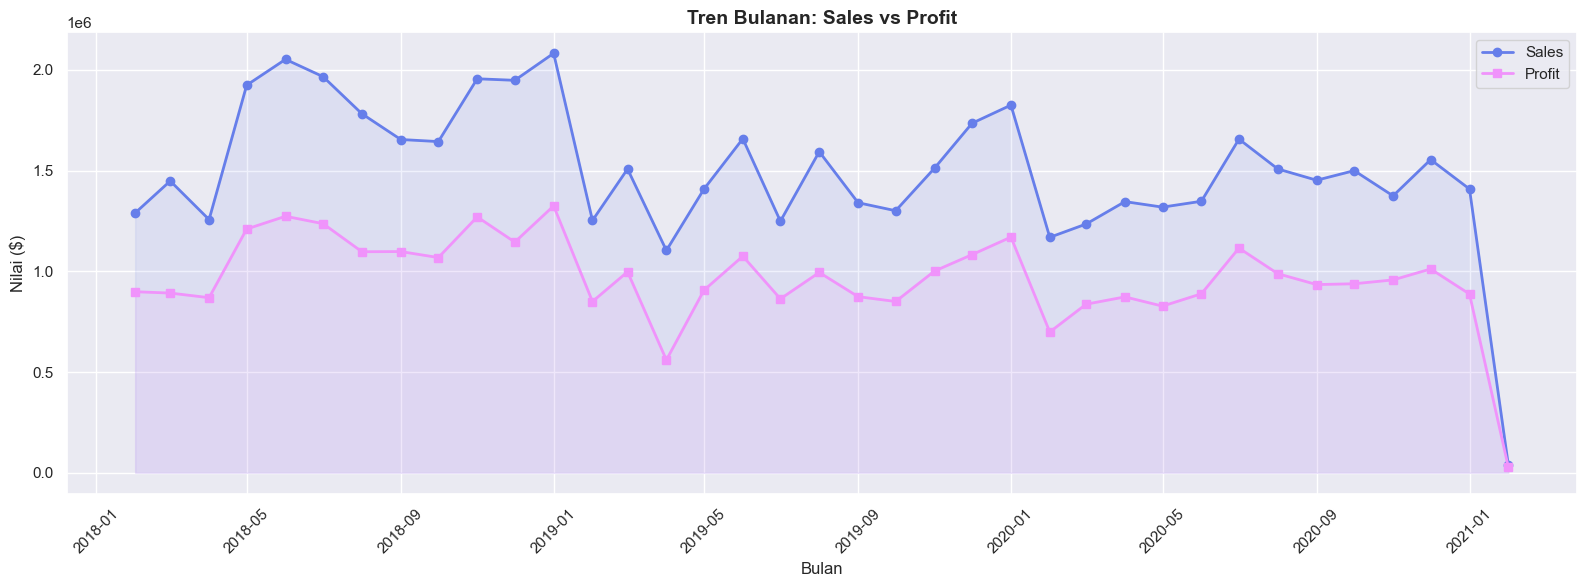

In [7]:
monthly = monthly_summary(df)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(monthly['order_month'], monthly['sales'], marker='o', label='Sales', color='#667eea', linewidth=2)
ax.plot(monthly['order_month'], monthly['profit'], marker='s', label='Profit', color='#f093fb', linewidth=2)
ax.fill_between(monthly['order_month'], monthly['sales'], alpha=0.1, color='#667eea')
ax.fill_between(monthly['order_month'], monthly['profit'], alpha=0.1, color='#f093fb')
ax.set_title('Tren Bulanan: Sales vs Profit', fontsize=14, fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Nilai ($)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

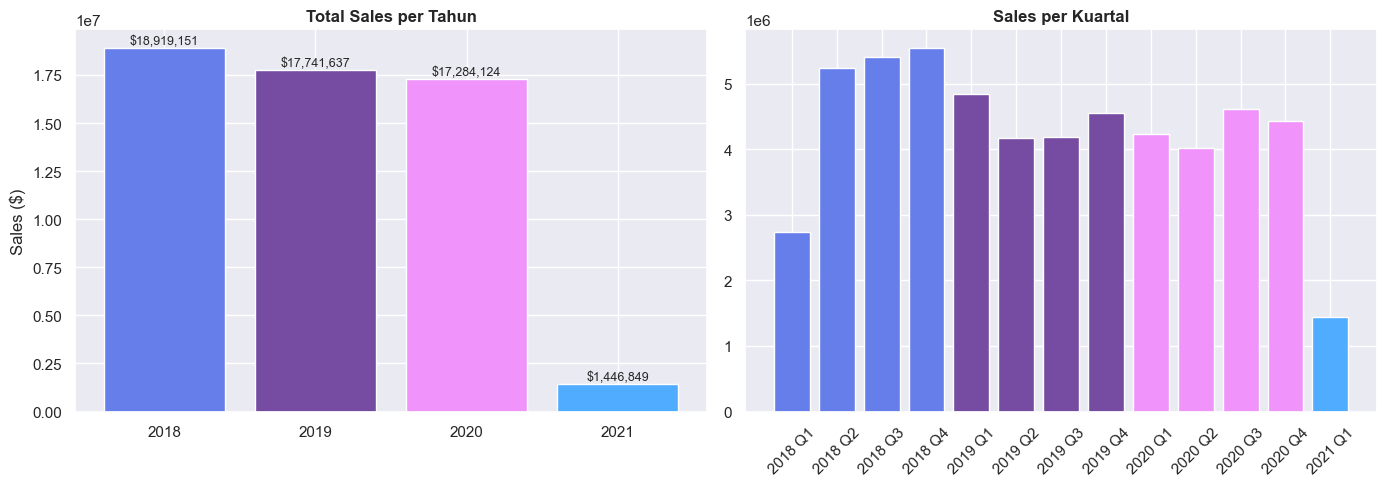

Year-over-Year Growth:
 year        sales  growth_pct
 2018 1.891915e+07         NaN
 2019 1.774164e+07   -6.223927
 2020 1.728412e+07   -2.578754
 2021 1.446849e+06  -91.629032


In [8]:
yearly = df.groupby('year')['sales'].sum().reset_index()
yearly['growth_pct'] = yearly['sales'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(yearly['year'].astype(str), yearly['sales'], color=['#667eea','#764ba2','#f093fb','#4facfe'])
axes[0].set_title('Total Sales per Tahun', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
for i, v in enumerate(yearly['sales']):
    axes[0].text(i, v + 200000, f'${v:,.0f}', ha='center', fontsize=9)

# Quarterly
df['quarter'] = df['order_date'].dt.quarter
qdf = df.groupby(['year','quarter'], as_index=False)['sales'].sum()
qdf['label'] = qdf['year'].astype(str) + ' Q' + qdf['quarter'].astype(str)
colors = ['#667eea' if y==2018 else '#764ba2' if y==2019 else '#f093fb' if y==2020 else '#4facfe' for y in qdf['year']]
axes[1].bar(qdf['label'], qdf['sales'], color=colors)
axes[1].set_title('Sales per Kuartal', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('Year-over-Year Growth:')
print(yearly[['year','sales','growth_pct']].to_string(index=False))

### Pertanyaan 2: Kontribusi Channel Penjualan

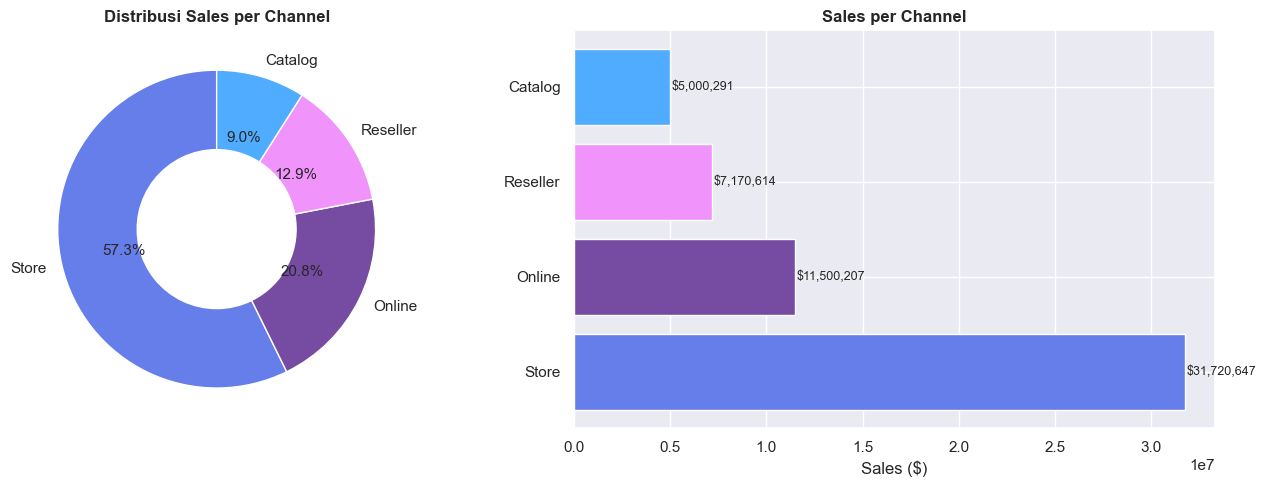

,channel,sales,profit,count
3,Store,3.172065e+07,2.045999e+07,9981
1,Online,1.150021e+07,7.349697e+06,2351
2,Reseller,7.170614e+06,4.498519e+06,1784
0,Catalog,5.000291e+06,3.281174e+06,884


In [9]:
channel_df = df.groupby('channel', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), count=('sales','count')
).sort_values('sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(channel_df['sales'], labels=channel_df['channel'], autopct='%1.1f%%',
            colors=['#667eea','#764ba2','#f093fb','#4facfe'], startangle=90,
            wedgeprops=dict(width=0.5))
axes[0].set_title('Distribusi Sales per Channel', fontweight='bold')

axes[1].barh(channel_df['channel'], channel_df['sales'], color=['#667eea','#764ba2','#f093fb','#4facfe'])
axes[1].set_title('Sales per Channel', fontweight='bold')
axes[1].set_xlabel('Sales ($)')
for i, v in enumerate(channel_df['sales']):
    axes[1].text(v + 100000, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
channel_df

### Pertanyaan 3: Performa Region

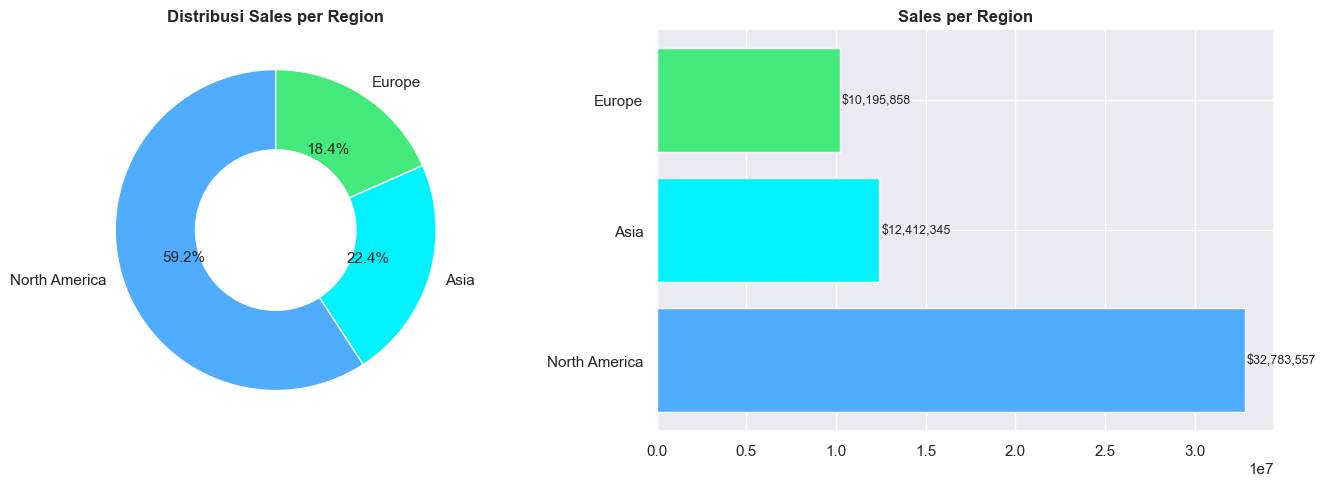

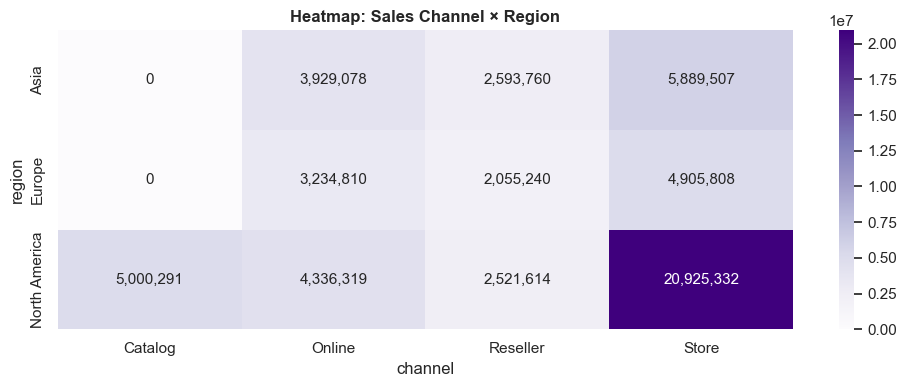

In [10]:
region_df = df.groupby('region', as_index=False).agg(
    sales=('sales','sum'), profit=('profit','sum'), count=('sales','count')
).sort_values('sales', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(region_df['sales'], labels=region_df['region'], autopct='%1.1f%%',
            colors=['#4facfe','#00f2fe','#43e97b'], startangle=90,
            wedgeprops=dict(width=0.5))
axes[0].set_title('Distribusi Sales per Region', fontweight='bold')

axes[1].barh(region_df['region'], region_df['sales'], color=['#4facfe','#00f2fe','#43e97b'])
axes[1].set_title('Sales per Region', fontweight='bold')
for i, v in enumerate(region_df['sales']):
    axes[1].text(v + 100000, i, f'${v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# Heatmap Channel x Region
cross = pd.crosstab(df['region'], df['channel'], values=df['sales'], aggfunc='sum').fillna(0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cross, annot=True, fmt=',.0f', cmap='Purples', ax=ax)
ax.set_title('Heatmap: Sales Channel × Region', fontweight='bold')
plt.tight_layout()
plt.show()

### Pertanyaan 4: Kategori dan Sub-Kategori Produk

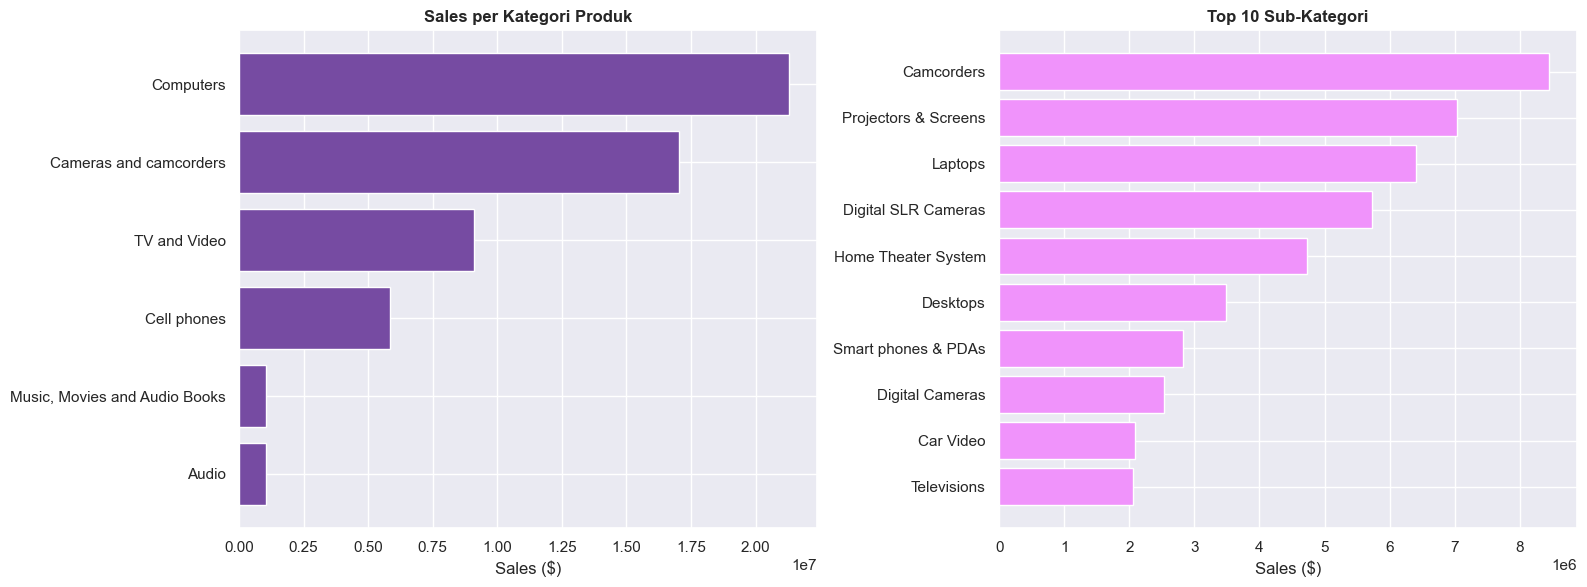

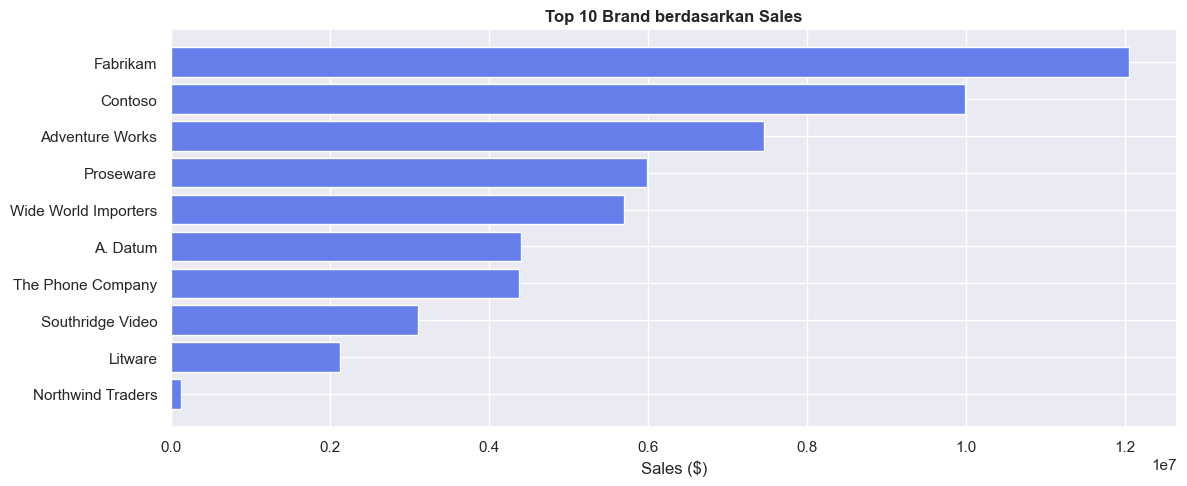

In [11]:
top_cat = top_n_by_metric(df, 'product_category', 'sales', 10)
top_sub = top_n_by_metric(df, 'product_sub_category', 'sales', 10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(top_cat.sort_values('sales')['product_category'], top_cat.sort_values('sales')['sales'], color='#764ba2')
axes[0].set_title('Sales per Kategori Produk', fontweight='bold')
axes[0].set_xlabel('Sales ($)')

axes[1].barh(top_sub.sort_values('sales')['product_sub_category'], top_sub.sort_values('sales')['sales'], color='#f093fb')
axes[1].set_title('Top 10 Sub-Kategori', fontweight='bold')
axes[1].set_xlabel('Sales ($)')
plt.tight_layout()
plt.show()

# Top Brands
top_brands = top_n_by_metric(df, 'brand_name', 'sales', 10)
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_brands.sort_values('sales')['brand_name'], top_brands.sort_values('sales')['sales'], color='#667eea')
ax.set_title('Top 10 Brand berdasarkan Sales', fontweight='bold')
ax.set_xlabel('Sales ($)')
plt.tight_layout()
plt.show()

### Pertanyaan 5: Profit Margin per Kategori dan Channel

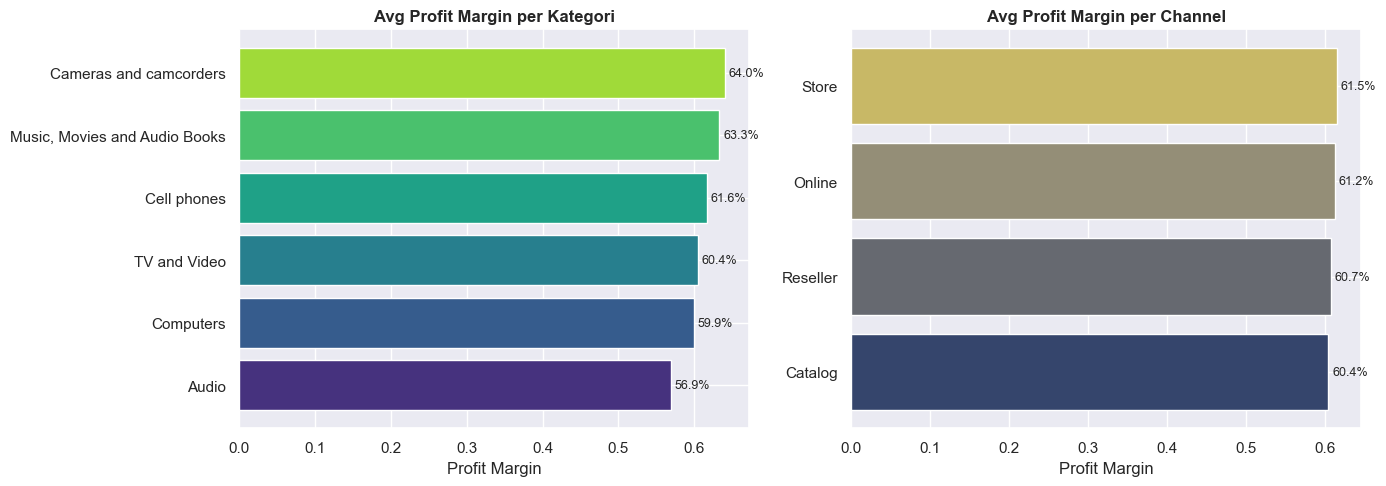

Overall Profit Margin: 64.25%


In [12]:
pm_cat = df.groupby('product_category', as_index=False)['profit_margin'].mean().sort_values('profit_margin')
pm_ch = df.groupby('channel', as_index=False)['profit_margin'].mean().sort_values('profit_margin')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars1 = axes[0].barh(pm_cat['product_category'], pm_cat['profit_margin'], color=sns.color_palette('viridis', len(pm_cat)))
axes[0].set_title('Avg Profit Margin per Kategori', fontweight='bold')
axes[0].set_xlabel('Profit Margin')
for bar, val in zip(bars1, pm_cat['profit_margin']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val*100:.1f}%', va='center', fontsize=9)

bars2 = axes[1].barh(pm_ch['channel'], pm_ch['profit_margin'], color=sns.color_palette('cividis', len(pm_ch)))
axes[1].set_title('Avg Profit Margin per Channel', fontweight='bold')
axes[1].set_xlabel('Profit Margin')
for bar, val in zip(bars2, pm_ch['profit_margin']):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val*100:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Overall Profit Margin: {(df['profit'].sum()/df['sales'].sum())*100:.2f}%")

### Pertanyaan 6: Transaksi dengan Profit Negatif

Total transaksi rugi: 1545 (10.3%)
Total kerugian: $2,724,761.94


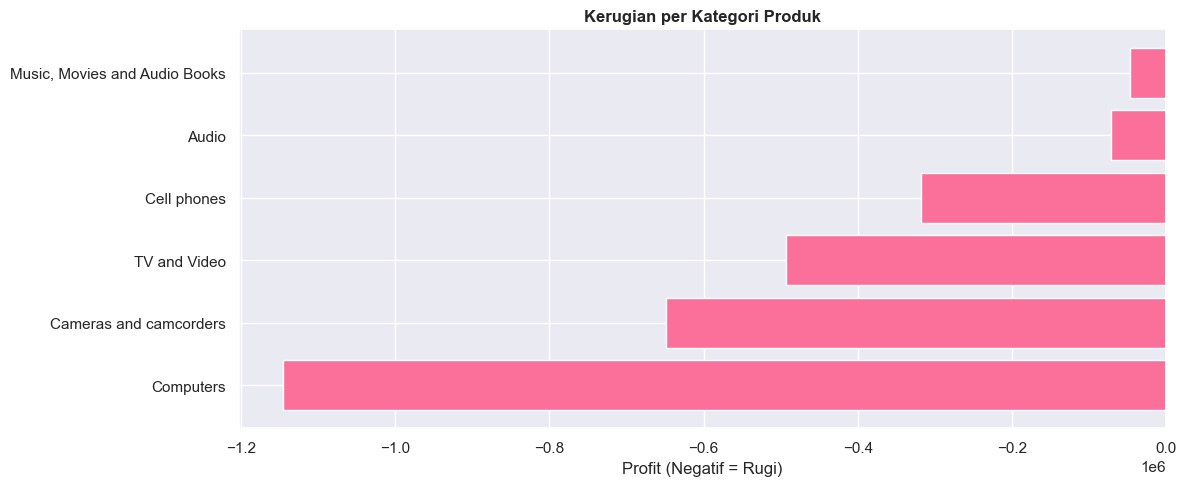

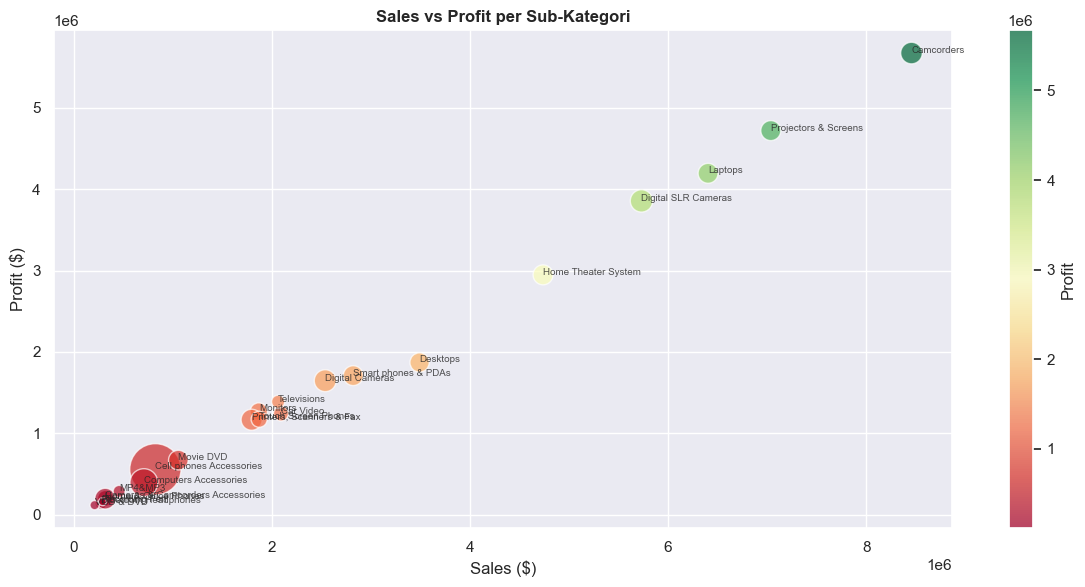

In [13]:
neg = df[df['profit'] < 0]
print(f'Total transaksi rugi: {len(neg)} ({len(neg)/len(df)*100:.1f}%)')
print(f'Total kerugian: ${abs(neg["profit"].sum()):,.2f}')

neg_cat = neg.groupby('product_category', as_index=False)['profit'].sum().sort_values('profit')
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(neg_cat['product_category'], neg_cat['profit'], color='#fa709a')
ax.set_title('Kerugian per Kategori Produk', fontweight='bold')
ax.set_xlabel('Profit (Negatif = Rugi)')
ax.axvline(x=0, color='white', linewidth=0.8)
plt.tight_layout()
plt.show()

# Scatter Sales vs Profit per Sub-Category
sp = df.groupby('product_sub_category', as_index=False).agg(sales=('sales','sum'), profit=('profit','sum'), qty=('order_qty','sum'))
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(sp['sales'], sp['profit'], s=sp['qty']/50, c=sp['profit'], cmap='RdYlGn', alpha=0.7, edgecolors='white')
ax.set_title('Sales vs Profit per Sub-Kategori', fontweight='bold')
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
plt.colorbar(scatter, label='Profit')
for _, row in sp.iterrows():
    ax.annotate(row['product_sub_category'], (row['sales'], row['profit']), fontsize=7, alpha=0.8)
plt.tight_layout()
plt.show()

### Pertanyaan 7: Performa per Negara dan Kota

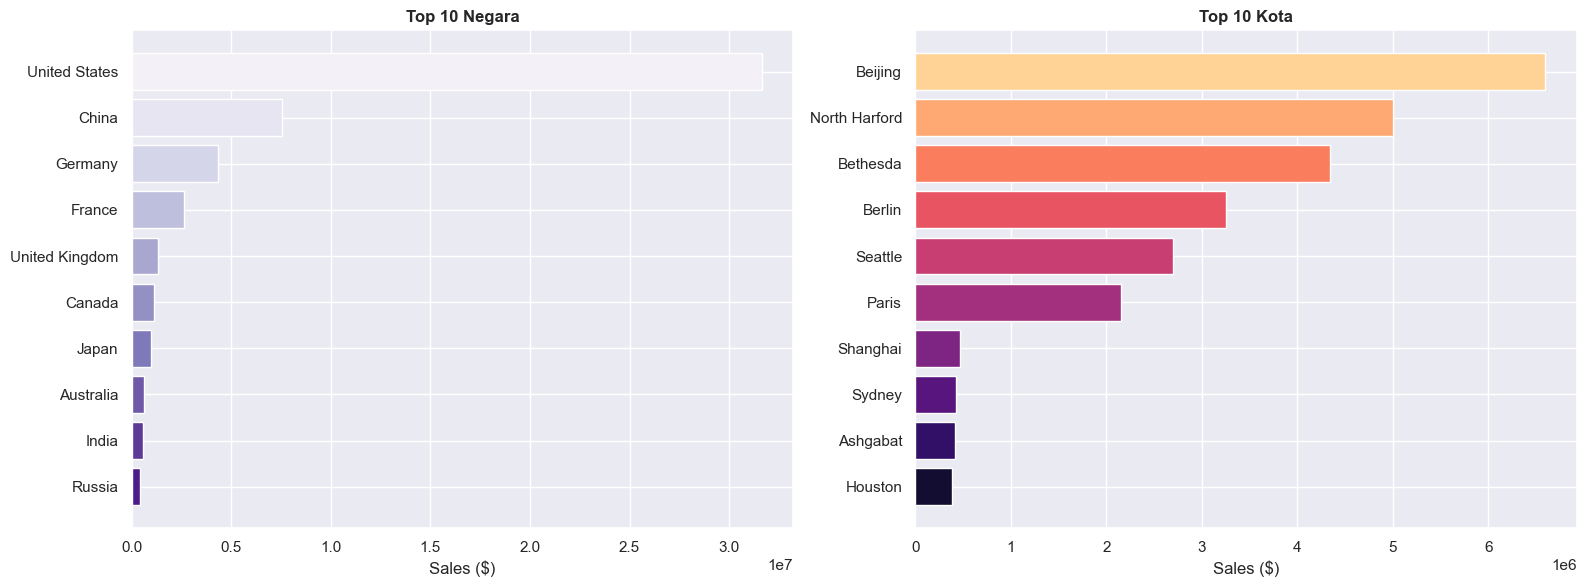

In [14]:
country_df = df.groupby('country', as_index=False).agg(sales=('sales','sum')).sort_values('sales', ascending=False).head(10)
city_df = df.groupby('city', as_index=False).agg(sales=('sales','sum')).sort_values('sales', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(country_df.sort_values('sales')['country'], country_df.sort_values('sales')['sales'], color=sns.color_palette('Purples_r', 10))
axes[0].set_title('Top 10 Negara', fontweight='bold')
axes[0].set_xlabel('Sales ($)')

axes[1].barh(city_df.sort_values('sales')['city'], city_df.sort_values('sales')['sales'], color=sns.color_palette('magma', 10))
axes[1].set_title('Top 10 Kota', fontweight='bold')
axes[1].set_xlabel('Sales ($)')
plt.tight_layout()
plt.show()

### Pertanyaan 8: Pola Penjualan per Hari

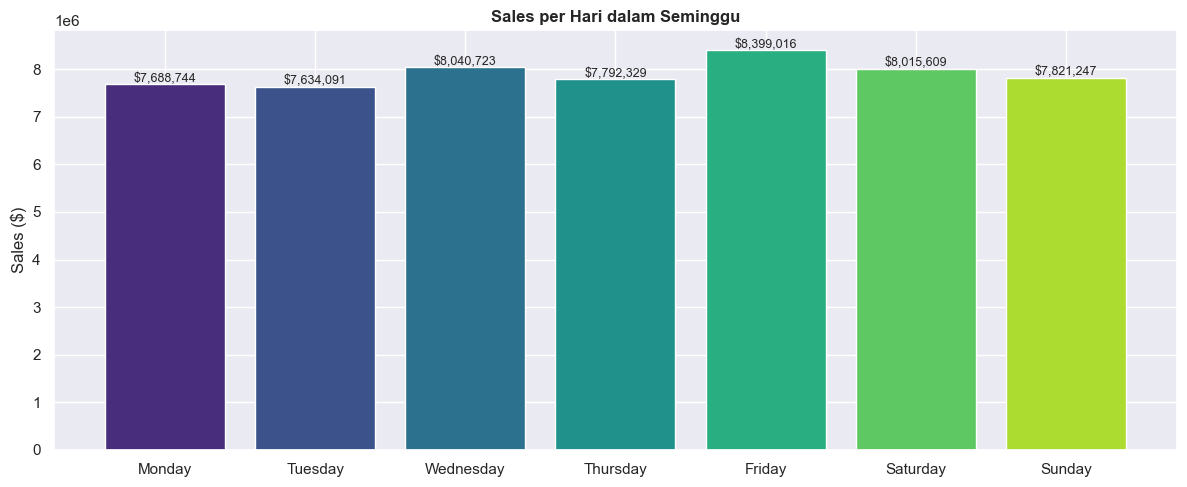

In [15]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('order_day_name', as_index=False).agg(sales=('sales','sum'), count=('sales','count'))
dow['order_day_name'] = pd.Categorical(dow['order_day_name'], categories=day_order, ordered=True)
dow = dow.sort_values('order_day_name')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(dow['order_day_name'], dow['sales'], color=sns.color_palette('viridis', 7))
ax.set_title('Sales per Hari dalam Seminggu', fontweight='bold')
ax.set_ylabel('Sales ($)')
for bar, val in zip(bars, dow['sales']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000, f'${val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Conclusion

### Jawaban Rumusan Masalah

| No | Pertanyaan | Jawaban |
|----|-----------|--------|
| 1 | Tren penjualan | Menurun YoY: -6.2% (2019), -2.6% (2020). Puncak di pertengahan & akhir tahun. |
| 2 | Channel terbaik | Store mendominasi 57.3% share dengan margin tertinggi (61.5%). |
| 3 | Region terbaik | North America 59.4% revenue. Asia & Europe masih punya ruang. |
| 4 | Kategori terlaris | Computers ($21.3M) & Cameras ($17.0M) = 69.3% total sales. |
| 5 | Profit margin | Overall 64.25%. Cameras tertinggi (64.0%), Audio terendah (56.9%). |
| 6 | Transaksi rugi | 1.545 (11.9%) rugi $2.7M. Computers paling terdampak (-$1.15M). |
| 7 | Geografi | USA ($31.6M) & China ($7.6M) terbesar. Beijing kota #1 ($6.6M). |
| 8 | Pola hari | Jumat tertinggi ($8.4M). Distribusi relatif merata. |

### 10 Insight Utama
1. **Tren Menurun YoY** — Penjualan turun konsisten dari $18.9M (2018) ke $17.3M (2020)
2. **Store Dominasi 57%** — Channel Store menyumbang lebih dari separuh total sales
3. **NA = 60% Revenue** — Ketergantungan tinggi pada North America
4. **2 Kategori = 69% Sales** — Computers & Cameras sangat mendominasi
5. **Cameras Margin Terbaik** — 64.0% margin dengan volume tinggi (golden goose)
6. **$2.7M Kerugian** — 11.9% transaksi rugi, Computers paling terdampak
7. **Beijing Kota #1** — Melebihi semua kota AS secara individual ($6.6M)
8. **Jumat Tertinggi** — Konsisten sebagai hari penjualan tertinggi
9. **Fabrikam Dominan** — 21.8% total sales. Top 5 brand = 74.4%
10. **Catalog Hanya di NA** — Peluang ekspansi ke Asia & Europe

### Rekomendasi Strategis
1. Atasi tren penurunan dengan diversifikasi produk & kampanye agresif
2. Optimalkan channel Online — potensi pertumbuhan terbesar
3. Ekspansi Catalog ke Asia & Europe
4. Investigasi kerugian $2.7M — audit pricing Computers
5. Perkuat pasar Asia (Beijing/China)
6. Leverage pola penjualan Jumat (Friday Deals)
7. Pertahankan investasi di kategori Cameras